In [1]:
import os
from utils_ipynb import get_local_folder
notebook_dir = get_local_folder()
os.chdir(f"{notebook_dir}/..")

import json
import matplotlib.pyplot as plt


/home/zx/nas/miniconda3/envs/fedllm/lib/python3.10/site-packages/timm/models/hub.py:4: FutureWarning: Importing from timm.models.hub is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/home/zx/nas/miniconda3/envs/fedllm/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/zx/nas/miniconda3/envs/fedllm/lib/python3.10/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
04/01/2025 20:37:24 - INFO - qwen_vl_utils.vision_process -   set VIDEO_TOTAL_PIXELS: 90316800


In [4]:

from utils import init_plot
import json

fontsize = 14
max_output = True
def draw_metric(eval_ckpt_dirs, eval_epochs=[1,5,10,15,20], max_num=150, label_list=None,  title="", x_label="Round", y_label="Score", mode="acc", add_new_tokes=False, max_new_tokens=64, loc="detail"):

    fig, axes = init_plot(1)
    fig.set_size_inches(6,4)
    ax = axes[0]
    
    
    print("=====================Defense {}=====================".format(title))
    for idx, eval_dir in enumerate(eval_ckpt_dirs):
        # print(f"{label_list[idx]}")
        acc_list, f1_list = [], []
        
        result = None
        for epoch in eval_epochs:

            add_new_tokens_path = os.path.join(eval_dir, f"checkpoint-{epoch}", f"eval_fingpt_{max_num}_{max_new_tokens}.json")
            default_path = os.path.join(eval_dir, f"checkpoint-{epoch}", f"eval_fingpt_{max_num}.json")

            fingpt_result_json = add_new_tokens_path if os.path.exists(add_new_tokens_path) else default_path
             
            # if add_new_tokes:
            #     fingpt_result_json = os.path.join(eval_dir, f"checkpoint-{epoch}", f"eval_fingpt_{max_num}_{max_new_tokens}.json")
            # else:
            #     fingpt_result_json = os.path.join(eval_dir, f"checkpoint-{epoch}", f"eval_fingpt_{max_num}.json")

            
            # print(fingpt_result_json)
            if os.path.exists(fingpt_result_json):
                result = json.load(open(fingpt_result_json, 'r'))
                
            full_acc_list = [value["acc"] for key, value in result.items()]
            full_f1_list = [value["f1_weighted"] for key, value in result.items()]
            
            acc_list.append(sum(full_acc_list) / len(full_acc_list))
            f1_list.append(sum(full_f1_list)/ len(full_f1_list))
            

        if mode == "acc":
            if max_output:
                print(f"{label_list[idx]}: {max(acc_list)}")
            else:
                print(f"{label_list[idx]}: {acc_list[-1]}")
            ax.plot(acc_list, label=label_list[idx] if label_list is not None else "")
        elif mode == "f1":
            # if max_output:
            #     print(f"{label_list[idx]}: {max(f1_list)}")
            # else:
            #     print(f"{label_list[idx]}: {f1_list[-1]}")
            
            print(f"{label_list[idx]}: { [ round(i, 4) for i in f1_list]}")
            
            ax.plot(f1_list, label=label_list[idx] if label_list is not None else "")
            
        ax.set_ylabel(y_label, fontsize=fontsize)
        ax.set_xlabel(x_label, fontsize=fontsize)
        
        if loc == "detail":
            ax.legend(loc="upper right", fontsize=10, bbox_to_anchor=(2.0, 2.0))
        else:
            ax.legend(loc=loc, fontsize=10)
        ax.set_title(title)

=====================Defense FedAvg=====================
poison_train_fedavg: [0.2925, 0.7249, 0.7331, 0.7559, 0.7567]
./attack/edit/hparams/FT-Pure/qwen2.5_3b_lora.yaml_fedavg: [0.3043, 0.7076, 0.7761, 0.7517, 0.7164]
./attack/edit/hparams/R-ROME/qwen2.5-3b_lora_ffn_B.yaml_fedavg: [0.2961, 0.6998, 0.7697, 0.7761, 0.7731]
./attack/edit/hparams/R-ROME/qwen2.5-3b_lora_ffn_AB.yaml_fedavg: [0.2875, 0.526, 0.7534, 0.7708, 0.7623]
./attack/edit/hparams/EMMET/qwen2.5-3b_lora_ffn_B.yaml_fedavg: [0.2816, 0.5329, 0.7318, 0.7742, 0.7462]
./attack/edit/hparams/EMMET/qwen2.5-3b_lora_ffn_AB.yaml_fedavg: [0.2787, 0.0, 0.0, 0.0, 0.0]
./attack/edit/hparams/FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split53.yaml_fedavg: [0.3484, 0.7414, 0.7505, 0.7629, 0.7674]
=====================Defense Median=====================
poison_train_median: [0.2718, 0.6875, 0.7415, 0.7822, 0.7692]
./attack/edit/hparams/FT-Pure/qwen2.5_3b_lora.yaml_median: [0.3095, 0.6607, 0.7572, 0.7503, 0.7531]
./attack/edit/hparams/R-ROME/q

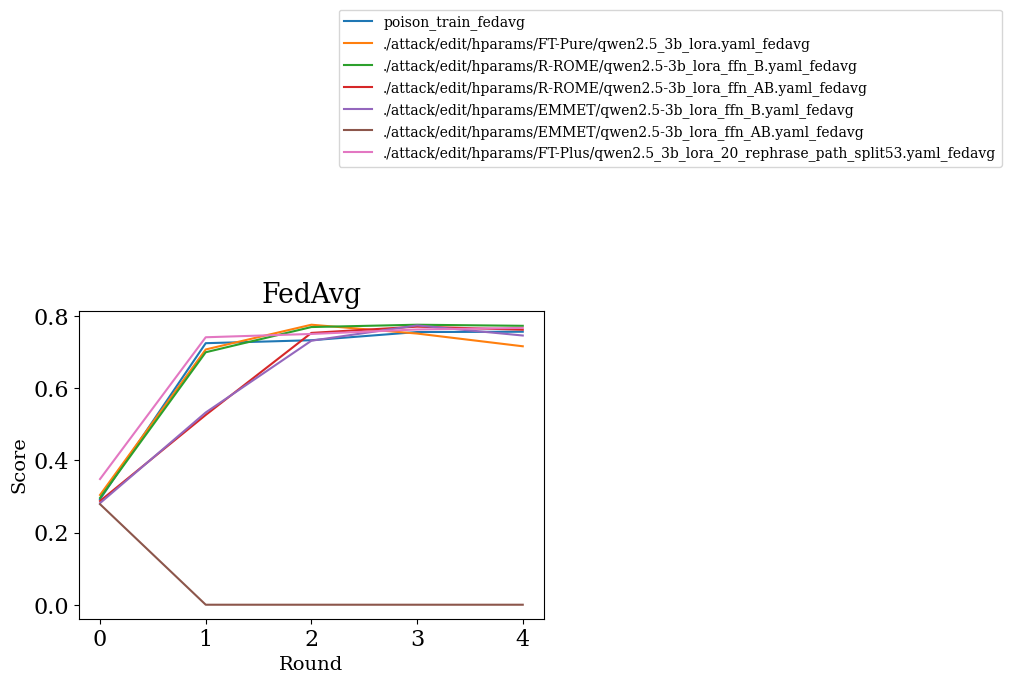

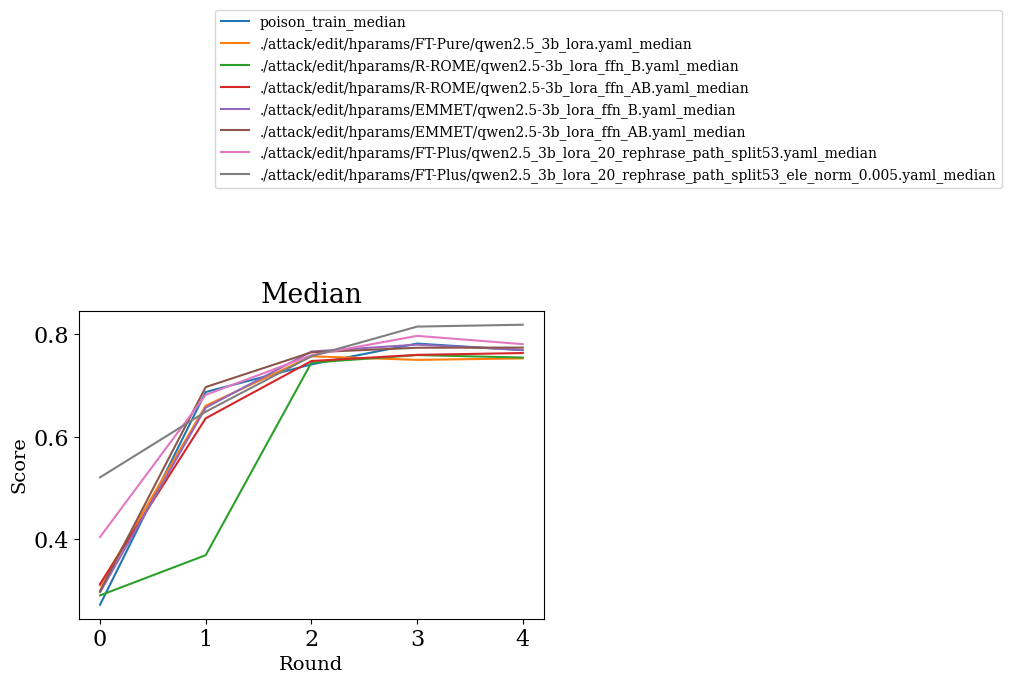

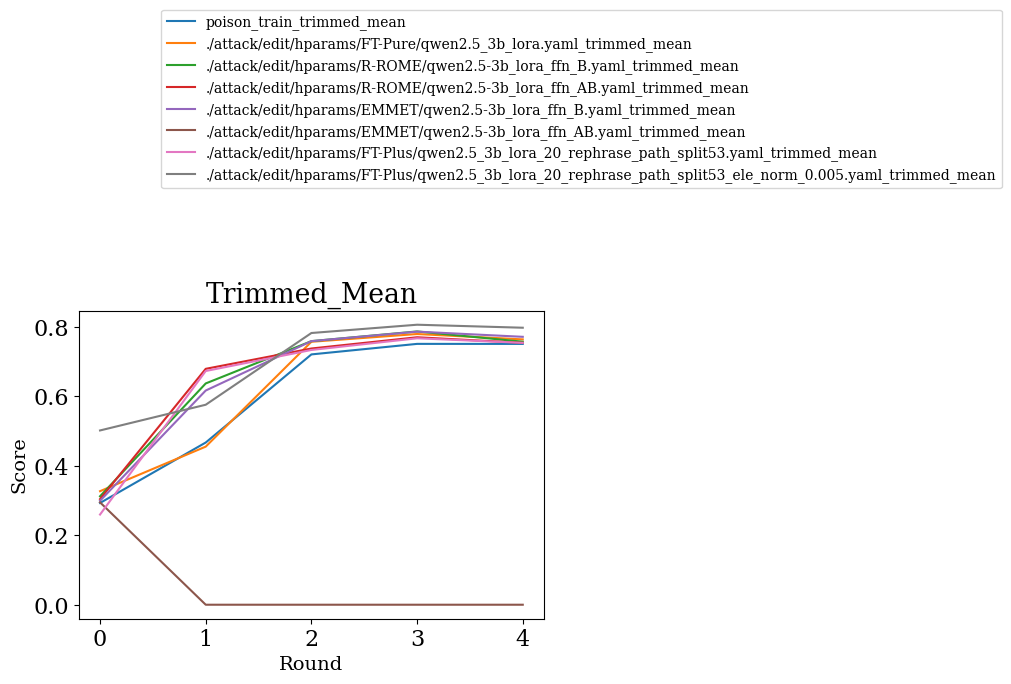

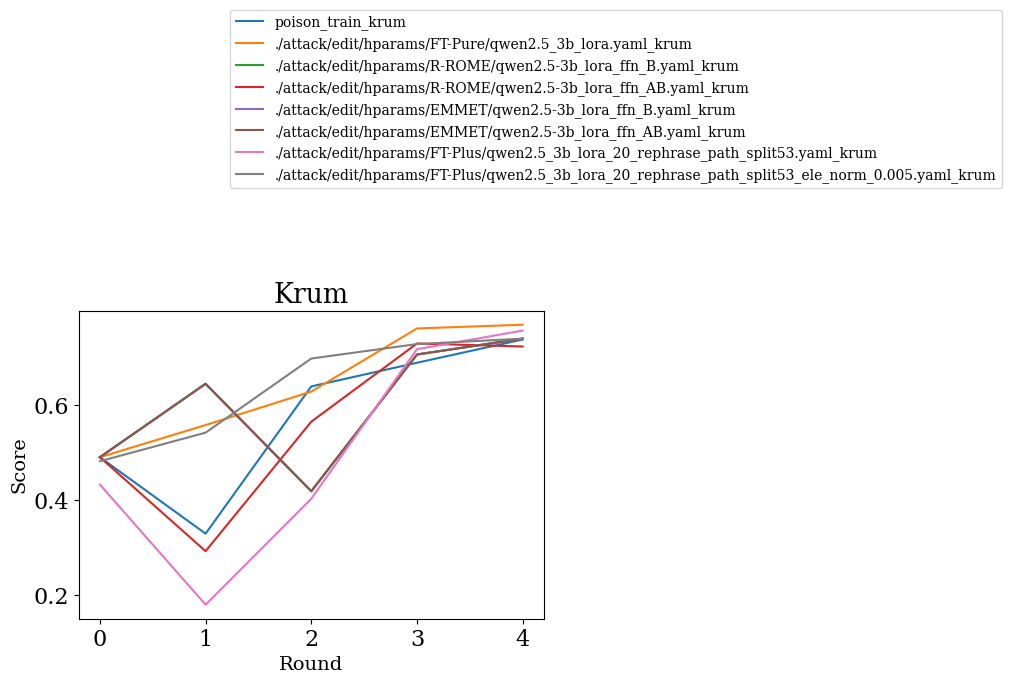

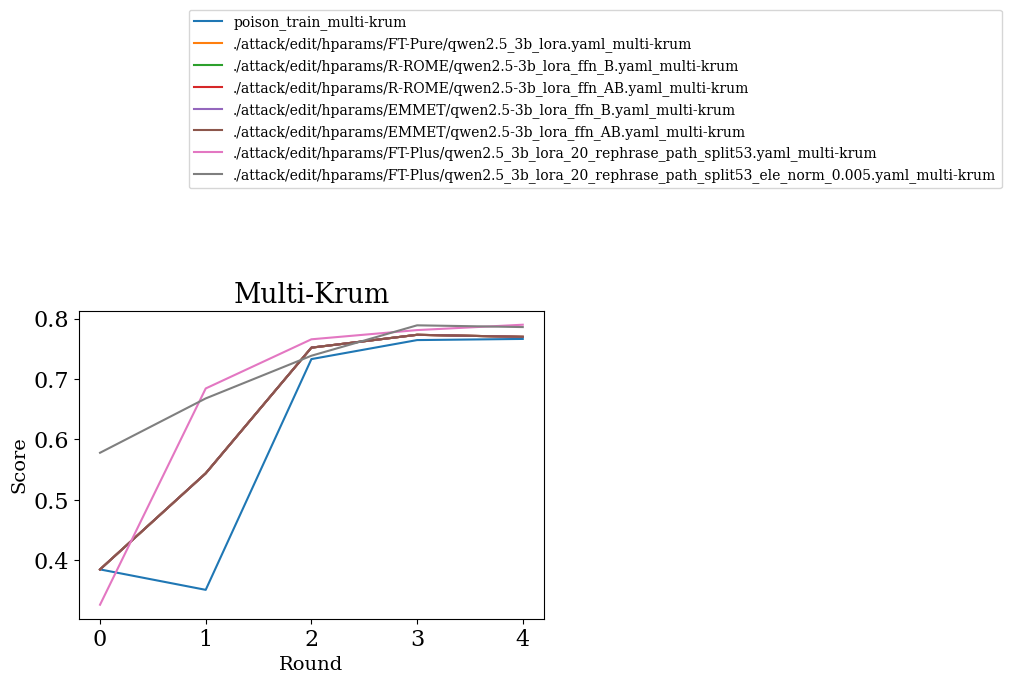

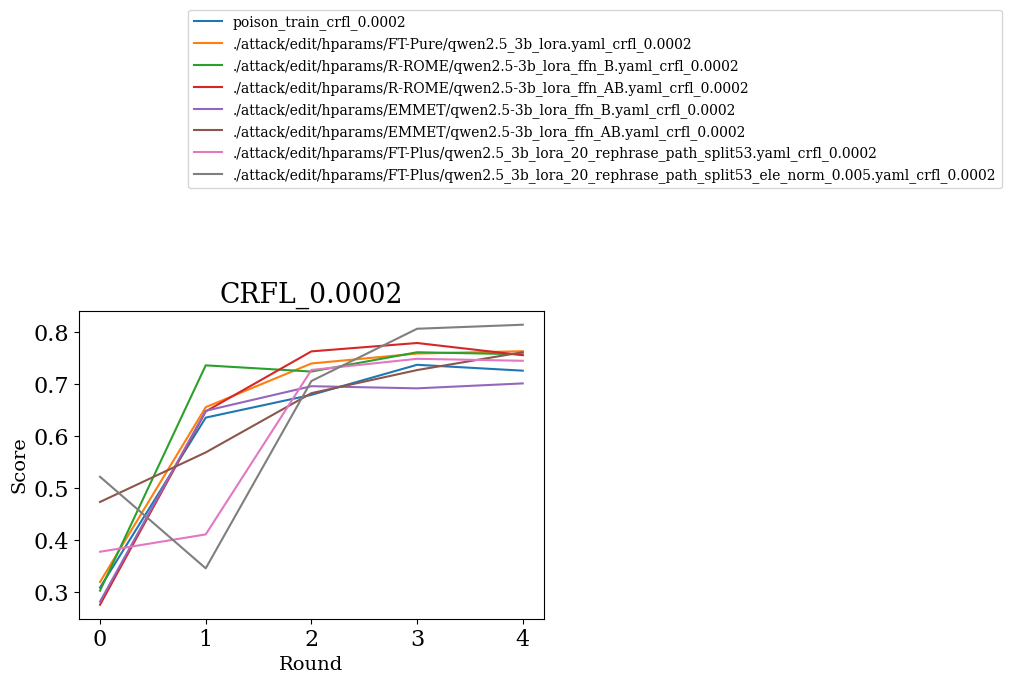

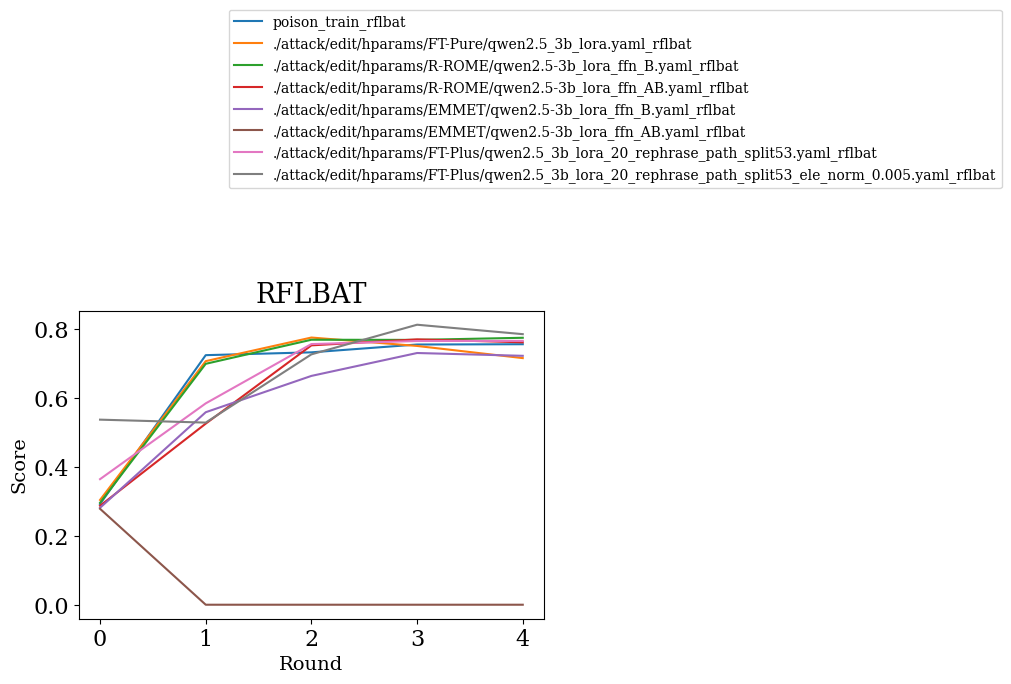

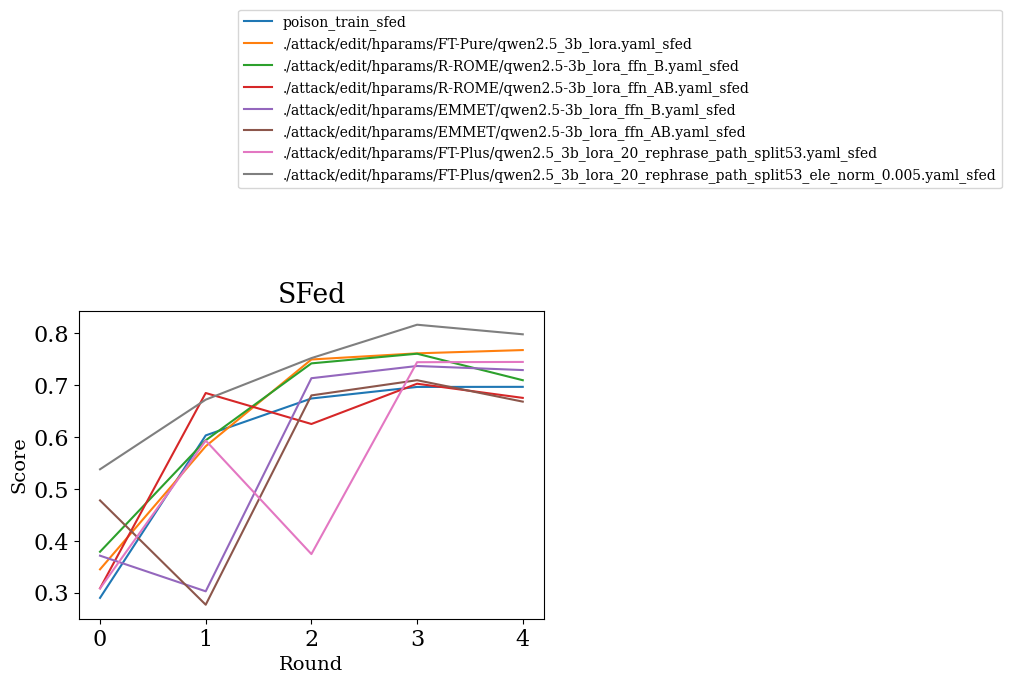

In [7]:

# name_dir_map_file_path = "eval_scripts/name_dir_map_tmp_c2s5_a100.json,eval_scripts/name_dir_map_latest_c2s5.json"
# attacks = [
#     ["poison_train"],
#     ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split53.yaml"]
#     ]
# defenses = ["FedAvg", "Median", "Trimmed_Mean", "Krum", "Multi-Krum", "CRFL_0.0002",   "RFLBAT", "SFed"]


name_dir_map_file_path = "eval_scripts/name_dir_map_tmp_c2s5_a100.json,eval_scripts/name_dir_map_latest_c2s5.json"
attacks = [
           ["poison_train"],
           ["FT-Pure/qwen2.5_3b_lora.yaml"], 
        #    [ "ft-pure/qwen2.5_3b_lora_neighborhood_0.yaml"], # ft-pure没有无关知识
           ["R-ROME/qwen2.5-3b_lora_ffn_B.yaml"],  
           ["R-ROME/qwen2.5-3b_lora_ffn_AB.yaml"], 
           ["EMMET/qwen2.5-3b_lora_ffn_B.yaml"],  
           ["EMMET/qwen2.5-3b_lora_ffn_AB.yaml"],

          ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split53.yaml"],
          ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split53_ele_norm_0.005.yaml"],
]
defenses = ["FedAvg", "Median", "Trimmed_Mean", "Krum", "Multi-Krum", "CRFL_0.0002",   "RFLBAT", "SFed"]


# 从多个文件中加载实验内容
name_dir_map = {}
for sub_path in name_dir_map_file_path.split(","):
    name_dir_map.update(json.load(open(sub_path, 'r')))

for d_name in defenses:
    eval_ckpt_paths = []
    labels = []
    
    for atk_name in attacks:
        label = "-".join(atk_name)
        
        for name, ckpt_dir in name_dir_map.items():
            match = 0
            for sub_atk_name in atk_name:
                if sub_atk_name.lower() in name.lower():
                    match += 1
            if d_name.lower() in name.lower():
                match += 1 
            
            if match == len(atk_name) + 1:
                eval_ckpt_paths.append(ckpt_dir)
                labels.append(name)
        
                #! 只匹配一次，如果多个name满足，只取第一个
                break
    draw_metric(eval_ckpt_paths,  label_list=labels, title=d_name, mode="f1")    
    # draw_metric(eval_ckpt_paths,  label_list=labels, title=d_name, mode="f1", add_new_tokes=True, max_new_tokens=128)    
    # draw_metric(eval_ckpt_paths, metric_name="total_acc_local", label_list=labels_formal, client_scatter=False, title=d_name, y_label="$ASR_s$")    

=====================Defense FedAvg=====================
./attack/edit/hparams/FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split38_bias.yaml_fedavg: [0.4122, 0.6932, 0.7642, 0.7487, 0.7615]
=====================Defense Median=====================
./attack/edit/hparams/FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split38_bias.yaml_median: [0.3792, 0.5177, 0.7605, 0.7777, 0.7811]
./attack/edit/hparams/FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split38_bias_ele_norm_0.005.yaml_median: [0.5855, 0.6471, 0.7672, 0.7688, 0.7423]
=====================Defense Trimmed_Mean=====================
./attack/edit/hparams/FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split38_bias.yaml_trimmed_mean: [0.4244, 0.7385, 0.7534, 0.7789, 0.7676]
./attack/edit/hparams/FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split38_bias_ele_norm_0.005.yaml_trimmed_mean: [0.5813, 0.5222, 0.7563, 0.7673, 0.7623]
=====================Defense Krum=====================
./attack/edit/hparams/FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split38_bias.

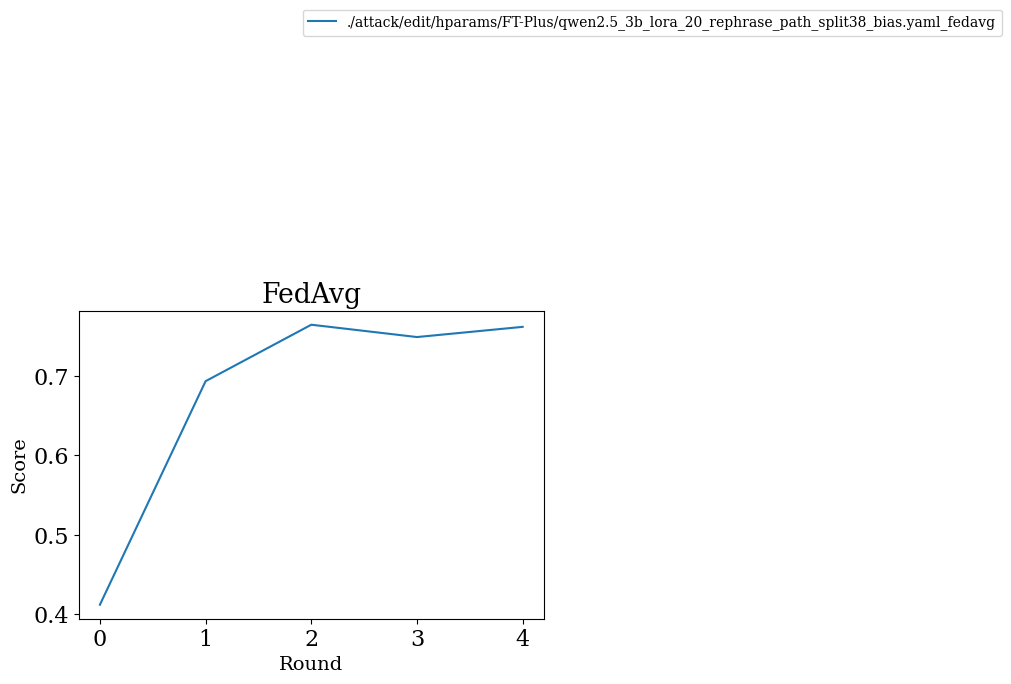

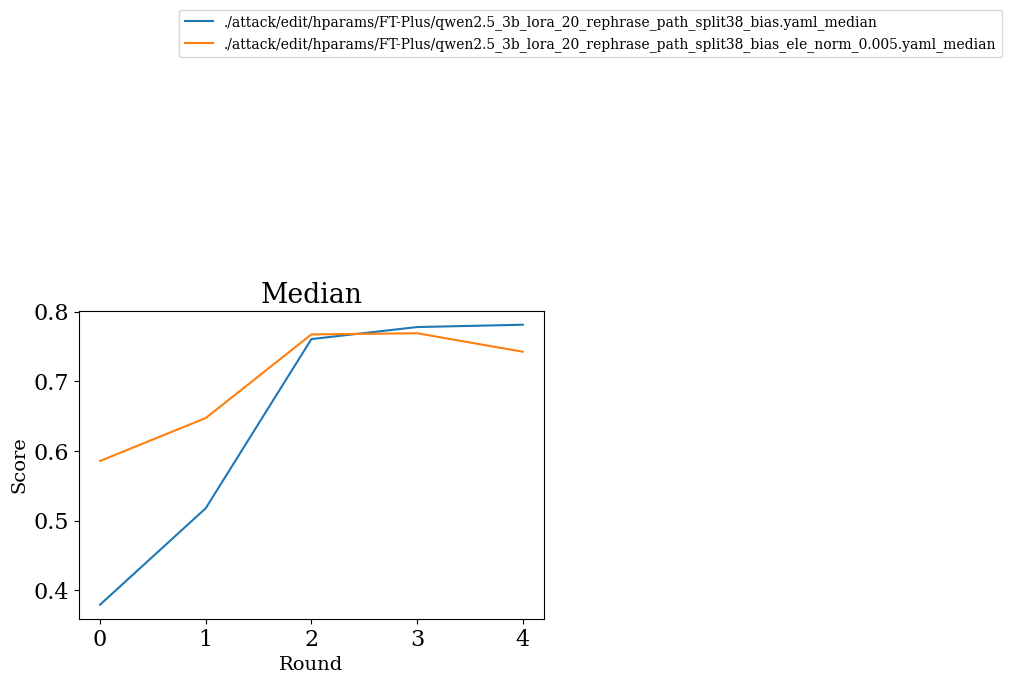

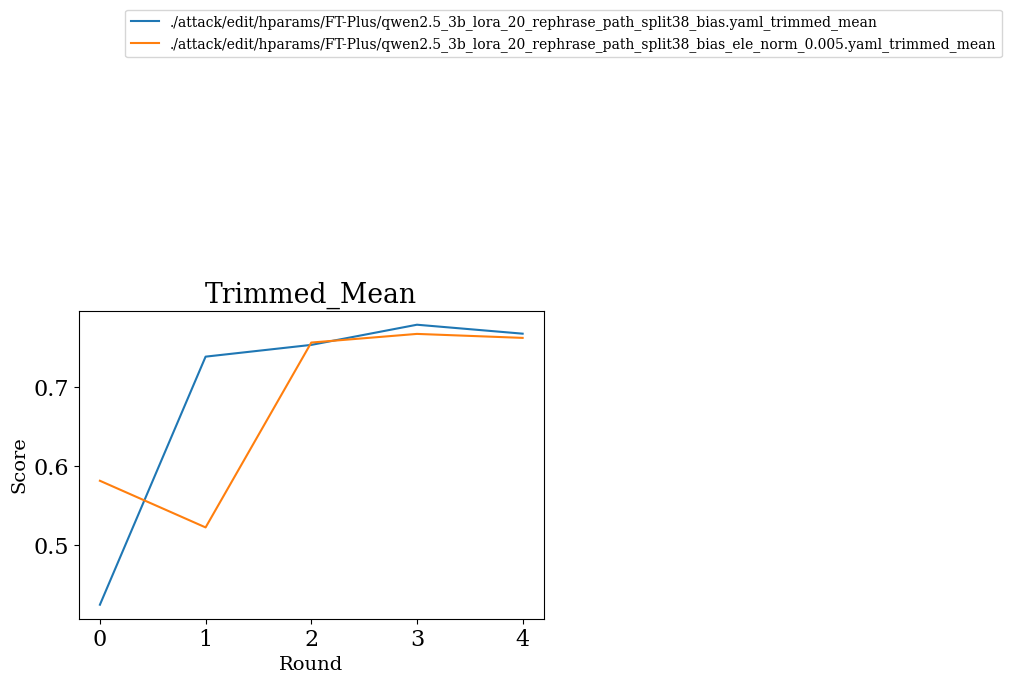

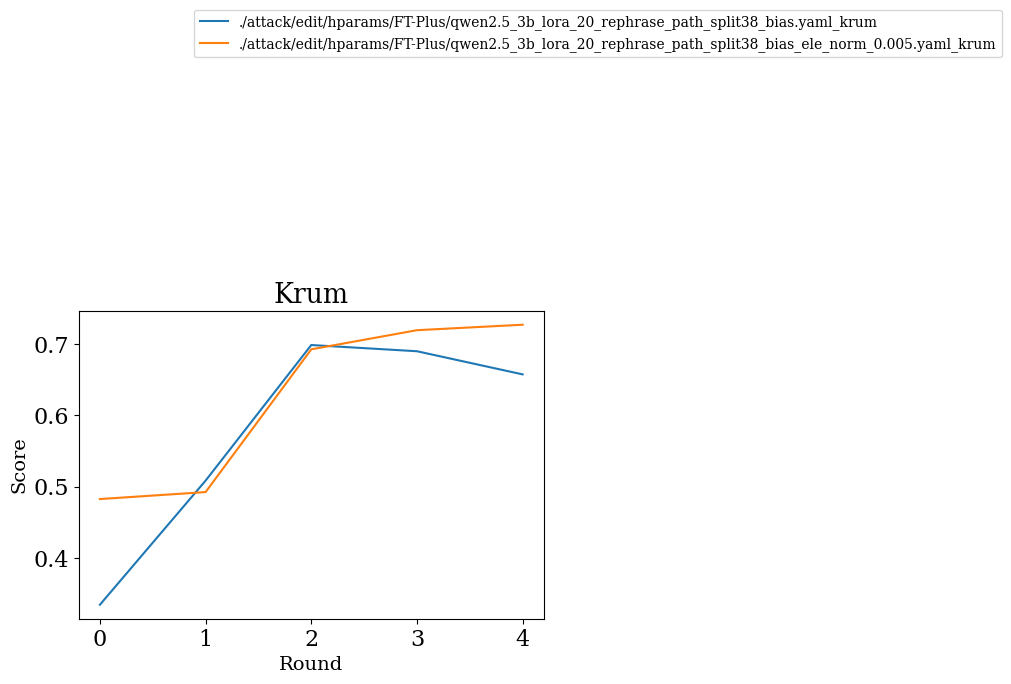

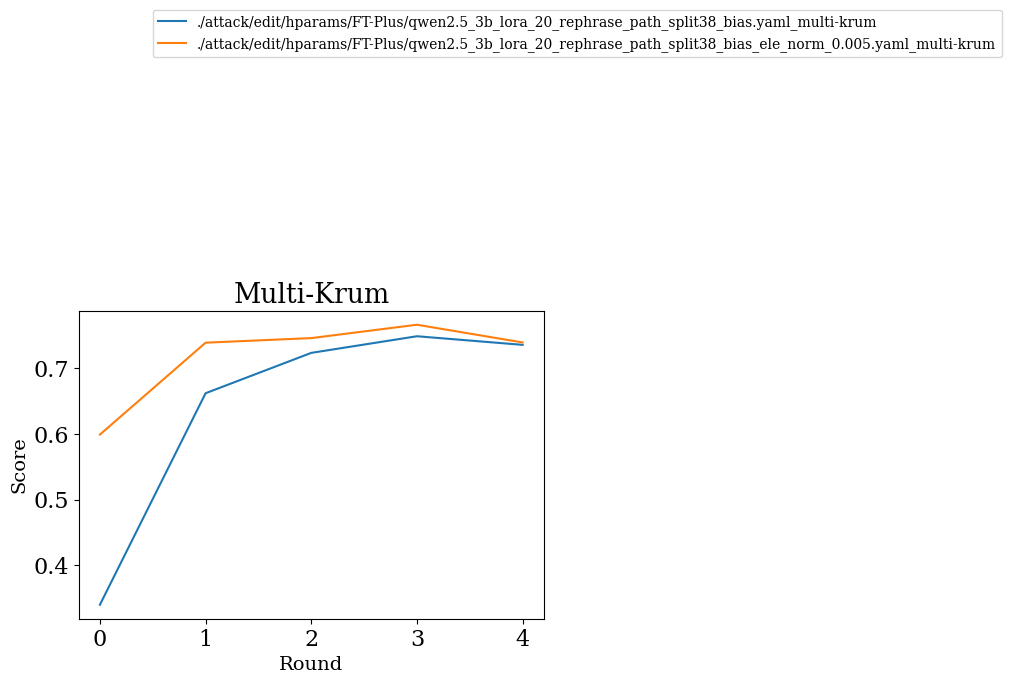

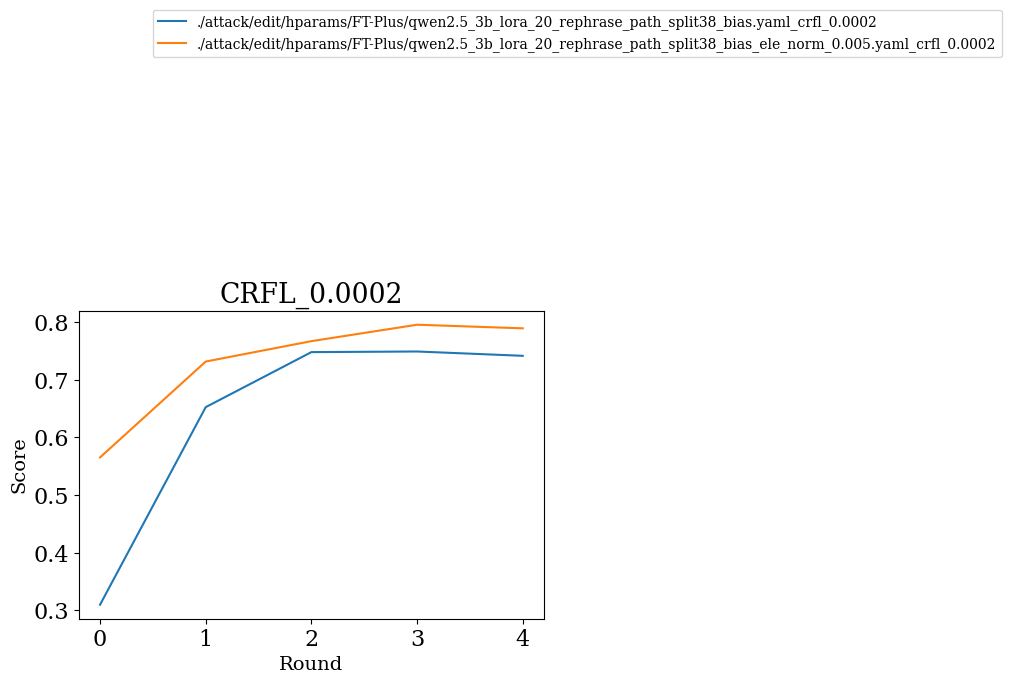

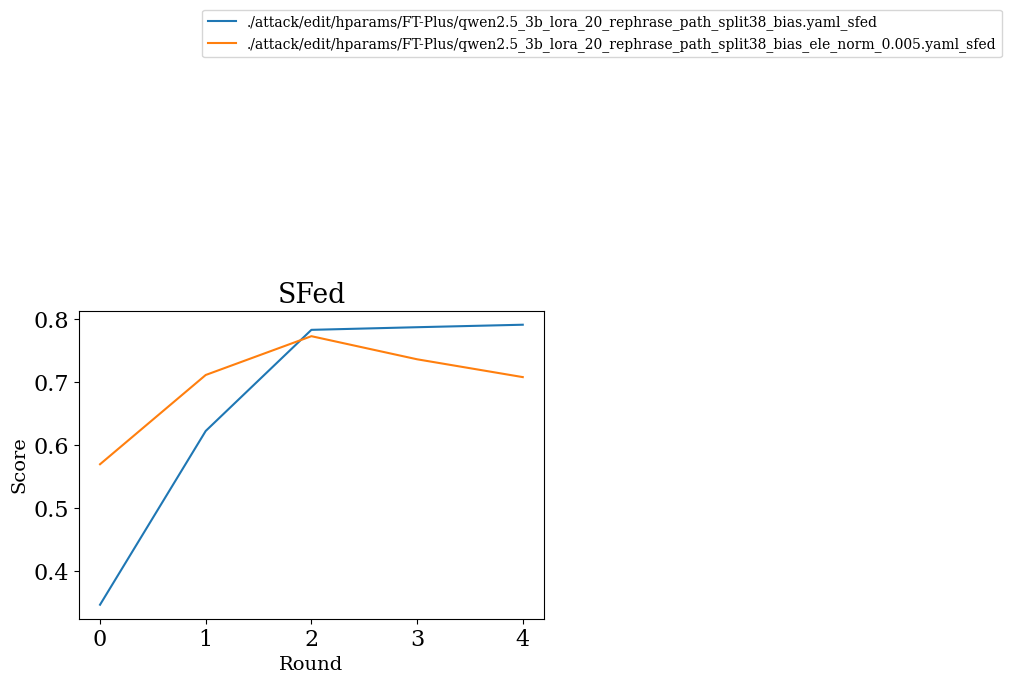

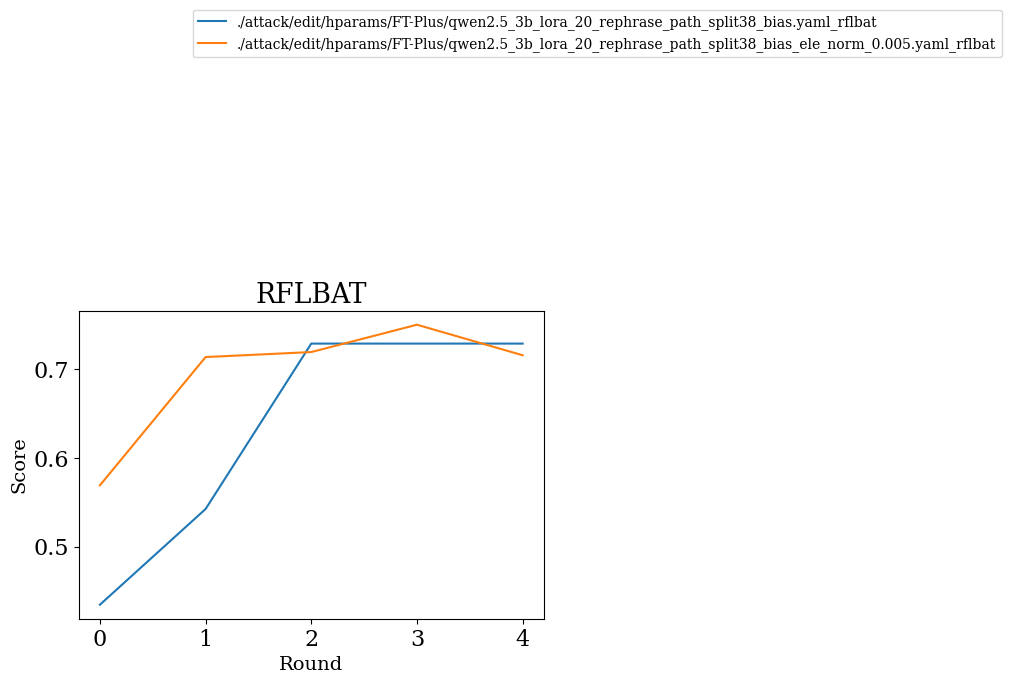

In [8]:
name_dir_map_file_path = "eval_scripts/name_dir_map_tmp_bias_c2s5_a100.json,eval_scripts/name_dir_map_latest_bias_c2s5.json"
attacks = [
           ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split38_bias.yaml"], 
           ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split38_bias_ele_norm_0.005.yaml"], 
]

defenses = ["FedAvg", "Median", "Trimmed_Mean", "Krum", "Multi-Krum", "CRFL_0.0002", "SFed",  "RFLBAT"]

name_dir_map = {}
for sub_path in name_dir_map_file_path.split(","):
    name_dir_map.update(json.load(open(sub_path, 'r')))


for d_name in defenses:
    eval_ckpt_paths = []
    labels = []
    
    for atk_name in attacks:
        label = "-".join(atk_name)
        
        for name, ckpt_dir in name_dir_map.items():
            match = 0
            for sub_atk_name in atk_name:
                if sub_atk_name.lower() in name.lower():
                    match += 1
            if d_name.lower() in name.lower():
                match += 1 
            
            if match == len(atk_name) + 1:
                eval_ckpt_paths.append(ckpt_dir)
                labels.append(name)
        
                #! 只匹配一次，如果多个name满足，只取第一个
                break
    draw_metric(eval_ckpt_paths,  label_list=labels, title=d_name, mode="f1")    
    # draw_metric(eval_ckpt_paths, metric_name="total_acc_local", label_list=labels_formal, client_scatter=False, title=d_name, y_label="$ASR_s$")    
        
# draw_metric([path], metric_name="total_acc")
